# Clusters, perception radius, and the obstacle

**Does the flock split around the obstacle, and does it come back together afterwards?**

Groups are the connected components of the perception graph — two agents are joined when one is
inside the other's perception radius, and an agent that sees nobody is a group of one. Unity records
the group sizes every frame in each clip's `k` field, so nothing is recomputed here.

The batch is one motion type at one randomness, swept over perception radius **and** max speed, with
every combination run from the same set of spawn layouts.

In [1]:
import json as _json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import same_start as sst

RECORDINGS = Path("../../Assets/SimulationRecordings/Combinations/20260908_013309_flocking_40")
CACHE = Path("../output/clusters_vs_perception/passage_cache.npz")
STRIDE = 5           # keep every 5th frame; at ~60 fps that is 12 samples a second

# This folder is 9 GB across 720 clips, so nothing is loaded whole. Each file is streamed once and
# reduced to the few series the questions need: time, centroid x, and group counts. The pose data,
# which is almost all of the bytes, is discarded as soon as the centroid is taken.
def extract(path, stride=STRIDE):
    d = _json.loads(path.read_text())
    h = d["header"]
    frames = d["frames"][::stride]
    if not frames:
        return None

    poses = [np.asarray(f["v"], dtype=float).reshape(-1, sst.STRIDE) for f in frames]
    sizes = [f.get("k") or [] for f in frames]

    obstacle_x = 0.0
    for g in h.get("geometry", []):
        if g.get("role") == "obstacle":
            obstacle_x = float(g["x"])
            break

    return {
        "R": round(float(h["perceptionRadius"]), 2),
        "speed": round(float(h["maxSpeed"]), 1),
        "random": round(float(h["randomMovement"])),
        "layout": h.get("spawnLayoutId", ""),
        "end": h.get("endReason", ""),
        "agents": int(h.get("agentCount", 0)),
        "t": np.array([f["t"] for f in frames]),
        "cx": np.array([p[:, 0].mean() for p in poses]),
        # Both readings of "a group", so MIN_GROUP can be switched without re-reading 9 GB.
        "groups1": np.array([len(k) for k in sizes]),
        "groups2": np.array([sum(1 for s in k if s >= 2) for k in sizes]),
        "largest": np.array([max(k) if k else 0 for k in sizes]),
        "obstacle_x": obstacle_x,
    }

if CACHE.exists():
    passage = list(np.load(CACHE, allow_pickle=True)["runs"])
    print(f"loaded {len(passage)} clips from {CACHE.name}")
else:
    files = [p for p in sorted(RECORDINGS.glob("*.json"))
             if p.stem != "batch_config" and not p.stem.endswith("_config")]
    passage = [x for x in (extract(p) for p in files) if x is not None]
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(CACHE, runs=np.array(passage, dtype=object))
    print(f"extracted {len(passage)} clips -> {CACHE.name}")

# 1 counts a lone agent as its own group, which is how the paper defines fragmentation.
# 2 ignores strays and counts only groups of two or more.
MIN_GROUP = 1
GROUPS = "groups1" if MIN_GROUP == 1 else "groups2"

radii = sorted({r["R"] for r in passage})
speeds = sorted({r["speed"] for r in passage})
OBSTACLE_X = float(np.median([r["obstacle_x"] for r in passage]))
colour = plt.cm.viridis(np.linspace(0.12, 0.9, len(radii)))
speed_colour = {speeds[0]: "#1f77b4", speeds[-1]: "#d62728"}

print(f"\nradii   : {radii}")
print(f"speeds  : {speeds}")
print(f"layouts : {len({r['layout'] for r in passage})}")
print(f"obstacle at x = {OBSTACLE_X:g}")

loaded 720 clips from passage_cache.npz

radii   : [0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0]
speeds  : [1.5, 3.0]
layouts : 40
obstacle at x = 0


## 1. What the folder holds

The layout count is the sample size behind every point below. If it is not the same for every
radius and speed, the conditions are unevenly sampled and their spreads are not comparable.

In [2]:
design = pd.DataFrame([{k: r[k] for k in ("R", "speed", "random", "layout", "end", "agents")}
                       for r in passage])

cells_table = design.pivot_table(index="R", columns="speed", values="layout",
                                 aggfunc="nunique").fillna(0).astype(int)
print("layouts per cell")
display(cells_table)

if cells_table.to_numpy().min() == cells_table.to_numpy().max():
    print(f"Evenly sampled: {cells_table.to_numpy().min()} layouts in every cell.")
else:
    print("UNEVEN: some cells have fewer layouts than others.")

print(f"\nclip end reasons: {dict(design['end'].value_counts())}")
print(f"agents per clip : {sorted(design['agents'].unique())}")
durations = [r["t"][-1] for r in passage]
print(f"durations       : {min(durations):.1f}-{max(durations):.1f}s  "
      f"— which is why the sections below use position rather than time")

layouts per cell


speed,1.5,3.0
R,,
0.5,40,40
1.0,40,40
1.5,40,40
1.8,40,40
2.0,40,40
2.5,40,40
3.0,40,40
3.5,40,40
4.0,40,40


Evenly sampled: 40 layouts in every cell.

clip end reasons: {'timeout': np.int64(637), 'goal-area': np.int64(83)}
agents per clip : [np.int64(40)]
durations       : 16.0-31.0s  — which is why the sections below use position rather than time


## 2. Group count over time

Two panels per row, each row scaled to its own range, because 30 groups and 3 groups cannot be read
on one axis.

This is the raw view. It mixes the two max speeds and it puts clips of different length on one axis,
both of which section 3 onwards fixes — it is here to show what the recordings look like before any
alignment.

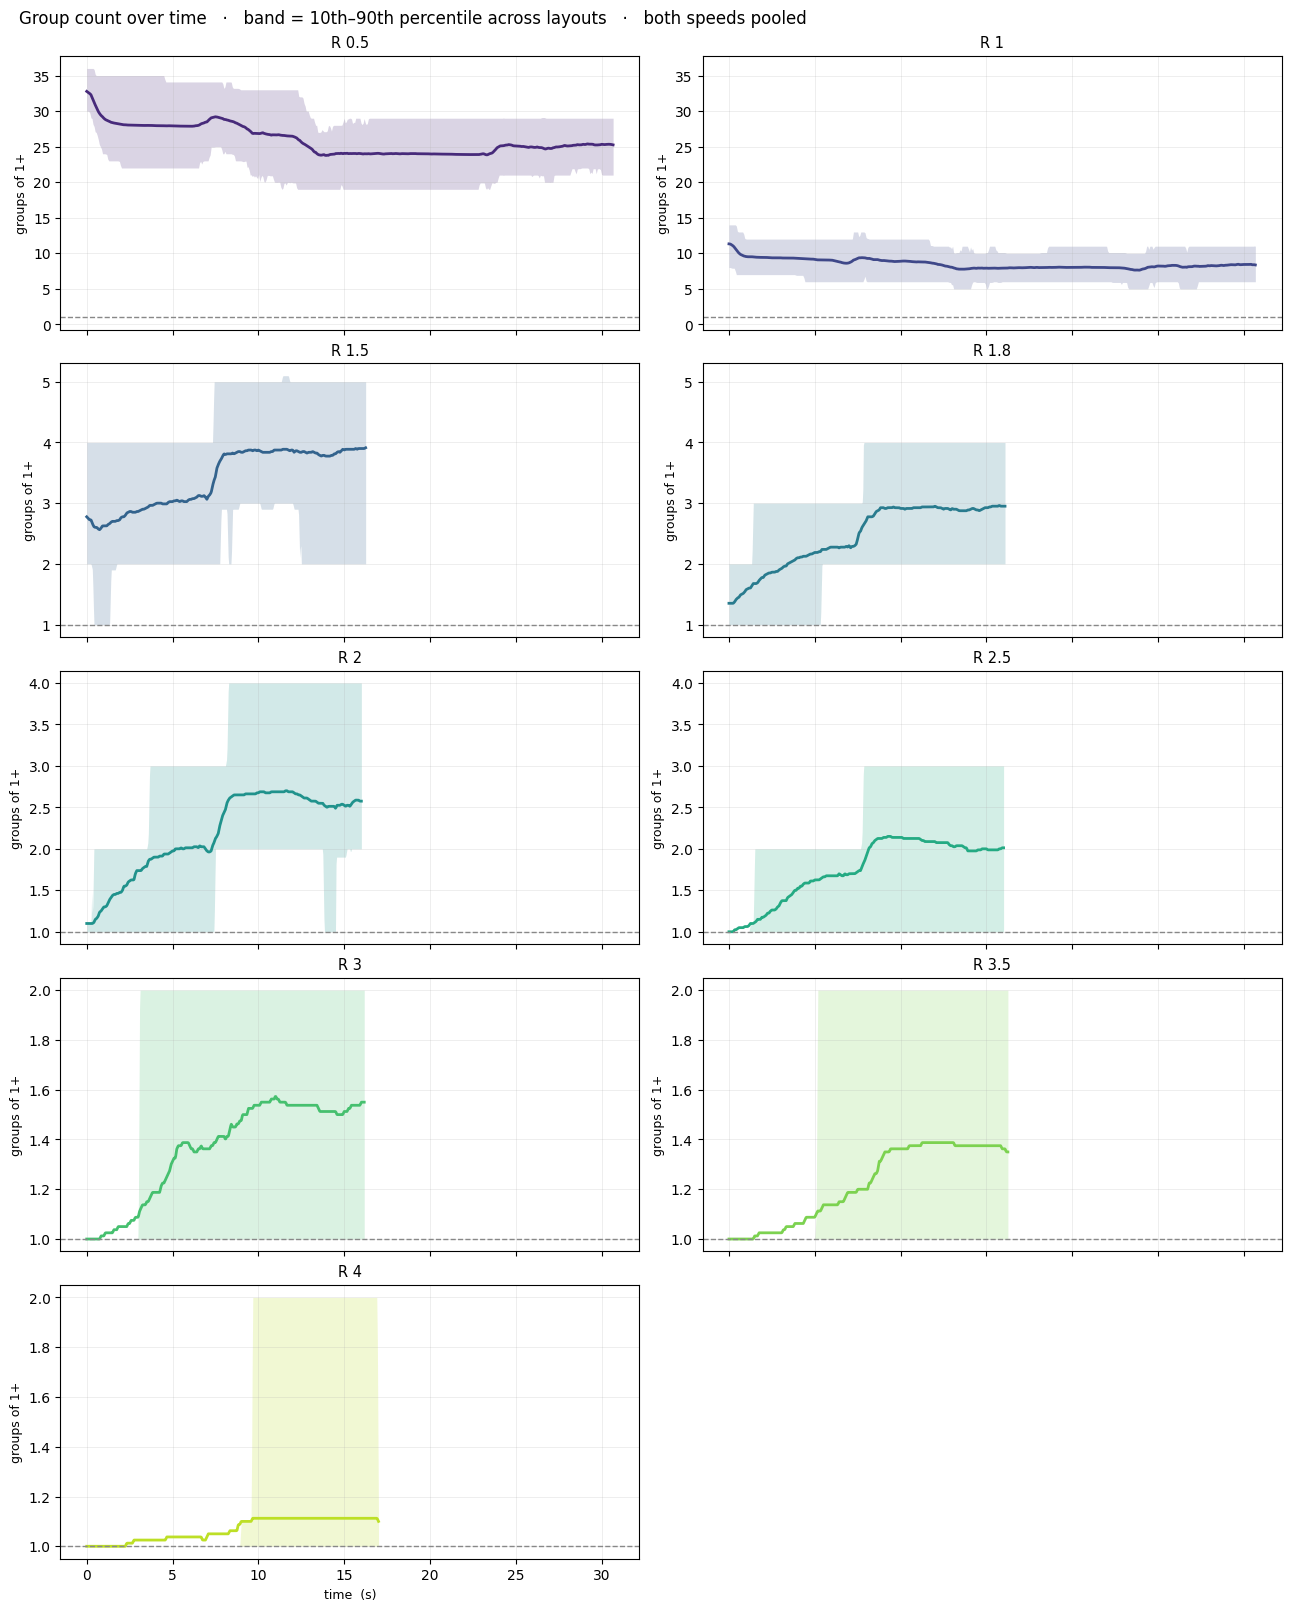

In [3]:
ncols = 2
nrows = int(np.ceil(len(radii) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6.4 * ncols, 3.2 * nrows),
                         sharex=True, squeeze=False, layout="constrained")

for index, (c, R) in enumerate(zip(colour, radii)):
    ax = axes[index // ncols][index % ncols]
    sel = [r for r in passage if r["R"] == R]

    span = min(float(r["t"][-1]) for r in sel)
    grid = np.linspace(0, span, 500)
    stack = np.array([np.interp(grid, r["t"], r[GROUPS]) for r in sel])

    ax.fill_between(grid, np.percentile(stack, 10, axis=0), np.percentile(stack, 90, axis=0),
                    color=c, alpha=0.20, linewidth=0)
    ax.plot(grid, stack.mean(axis=0), lw=2.0, color=c)
    ax.axhline(1, color="#888888", ls="--", lw=1)
    ax.set_title(f"R {R:g}", fontsize=10.5)
    ax.set_ylabel(f"groups of {MIN_GROUP}+", fontsize=9)
    ax.grid(alpha=0.25, lw=0.6)

for index in range(len(radii), nrows * ncols):
    axes[index // ncols][index % ncols].axis("off")

for row in range(nrows):
    used = [axes[row][c] for c in range(ncols) if row * ncols + c < len(radii)]
    if used:
        lo = min(a.get_ylim()[0] for a in used)
        hi = max(a.get_ylim()[1] for a in used)
        for a in used:
            a.set_ylim(lo, hi)

for c in range(ncols):
    axes[-1][c].set_xlabel("time  (s)", fontsize=9)

fig.suptitle("Group count over time   ·   band = 10th–90th percentile across layouts   ·   "
             "both speeds pooled", fontsize=12, ha="left", x=0.01)
plt.show()

## 3. The obstacle, and why position beats time

The question is whether the flock splits around the obstacle and re-forms afterwards. Time is the
wrong axis for that, for two reasons:

- clips run **16 to 31 s**, because some end early on the goal area, so "the last frame" is a
  different point in the journey for different clips
- this batch has **two max speeds**, so the same moment in the journey happens at different times

The obstacle is a fixed box at **x = 0**, and the swarm travels from x ≈ −19 to the goal area at
x ≈ 25. Plotting against the swarm's centroid x instead of time aligns every clip on the same
journey and makes the two speeds directly comparable.

Reading 720 clips whole would be several gigabytes, so each file is streamed once, subsampled, and
reduced to three series — time, centroid x, group count — then cached.

### Zones along the journey

Three stretches of the journey, defined by where the swarm's centroid is relative to the obstacle:

- **before** — approaching, still clear of it
- **at** — passing it
- **after** — through, and before the goal area starts crowding the swarm back together

The "after" zone deliberately stops short of the goal area at x ≈ 22, because agents funnelling into
a target would re-merge for reasons that have nothing to do with the obstacle.

In [4]:
BEFORE = (-19.0, -5.0)
AT     = ( -2.5,  2.5)
AFTER  = (  5.0, 20.0)

def zone_groups(run, lo, hi):
    """Median group count while the centroid is inside a stretch of the journey."""
    m = (run["cx"] >= lo) & (run["cx"] <= hi)
    return float(np.median(run[GROUPS][m])) if m.any() else np.nan

def zone_peak(run, lo, hi):
    m = (run["cx"] >= lo) & (run["cx"] <= hi)
    return float(np.max(run[GROUPS][m])) if m.any() else np.nan

rows = []
for r in passage:
    rows.append({
        "R": r["R"], "speed": r["speed"], "layout": r["layout"],
        "before": zone_groups(r, *BEFORE),
        "at":     zone_groups(r, *AT),
        "at_peak":zone_peak(r,   *AT),
        "after":  zone_groups(r, *AFTER),
        "reached_after": bool(((r["cx"] >= AFTER[0]) & (r["cx"] <= AFTER[1])).any()),
    })

passage_df = pd.DataFrame(rows)
missing = (~passage_df["reached_after"]).sum()
print(f"{len(passage_df)} clips, {missing} never reached the 'after' zone "
      f"(they are excluded from the recovery numbers).")
display(passage_df.groupby(["speed", "R"])[["before", "at", "at_peak", "after"]].mean().round(2))

720 clips, 0 never reached the 'after' zone (they are excluded from the recovery numbers).


before     at  at_peak  after
speed R                                 
1.5   0.5   30.30  26.12    30.28  25.75
      1.0    9.90   7.78     9.45   7.90
      1.5    3.10   3.15     3.65   3.35
      1.8    2.12   2.42     2.78   2.68
      2.0    1.98   2.12     2.40   2.25
      2.5    1.65   1.64     1.85   1.75
      3.0    1.26   1.40     1.50   1.50
      3.5    1.09   1.30     1.40   1.38
      4.0    1.05   1.10     1.10   1.08
3.0   0.5   25.65  26.91    28.65  22.58
      1.0    8.65   8.28     9.90   8.30
      1.5    2.84   3.32     4.53   4.50
      1.8    1.88   2.31     3.20   3.35
      2.0    1.65   2.09     2.95   3.15
      2.5    1.25   1.86     2.30   2.42
      3.0    1.09   1.38     1.58   1.65
      3.5    1.02   1.15     1.25   1.45
      4.0    1.04   1.06     1.10   1.10

## 4. Group count along the journey

One panel per radius, two to a row, each row scaled to its own range. The x-axis is the swarm's
position, not time, so the obstacle is a fixed vertical line in every panel and the two speeds lie
on top of each other.

A flock that splits around the obstacle and re-forms shows as a bump: flat, rising at x = 0, then
falling back.

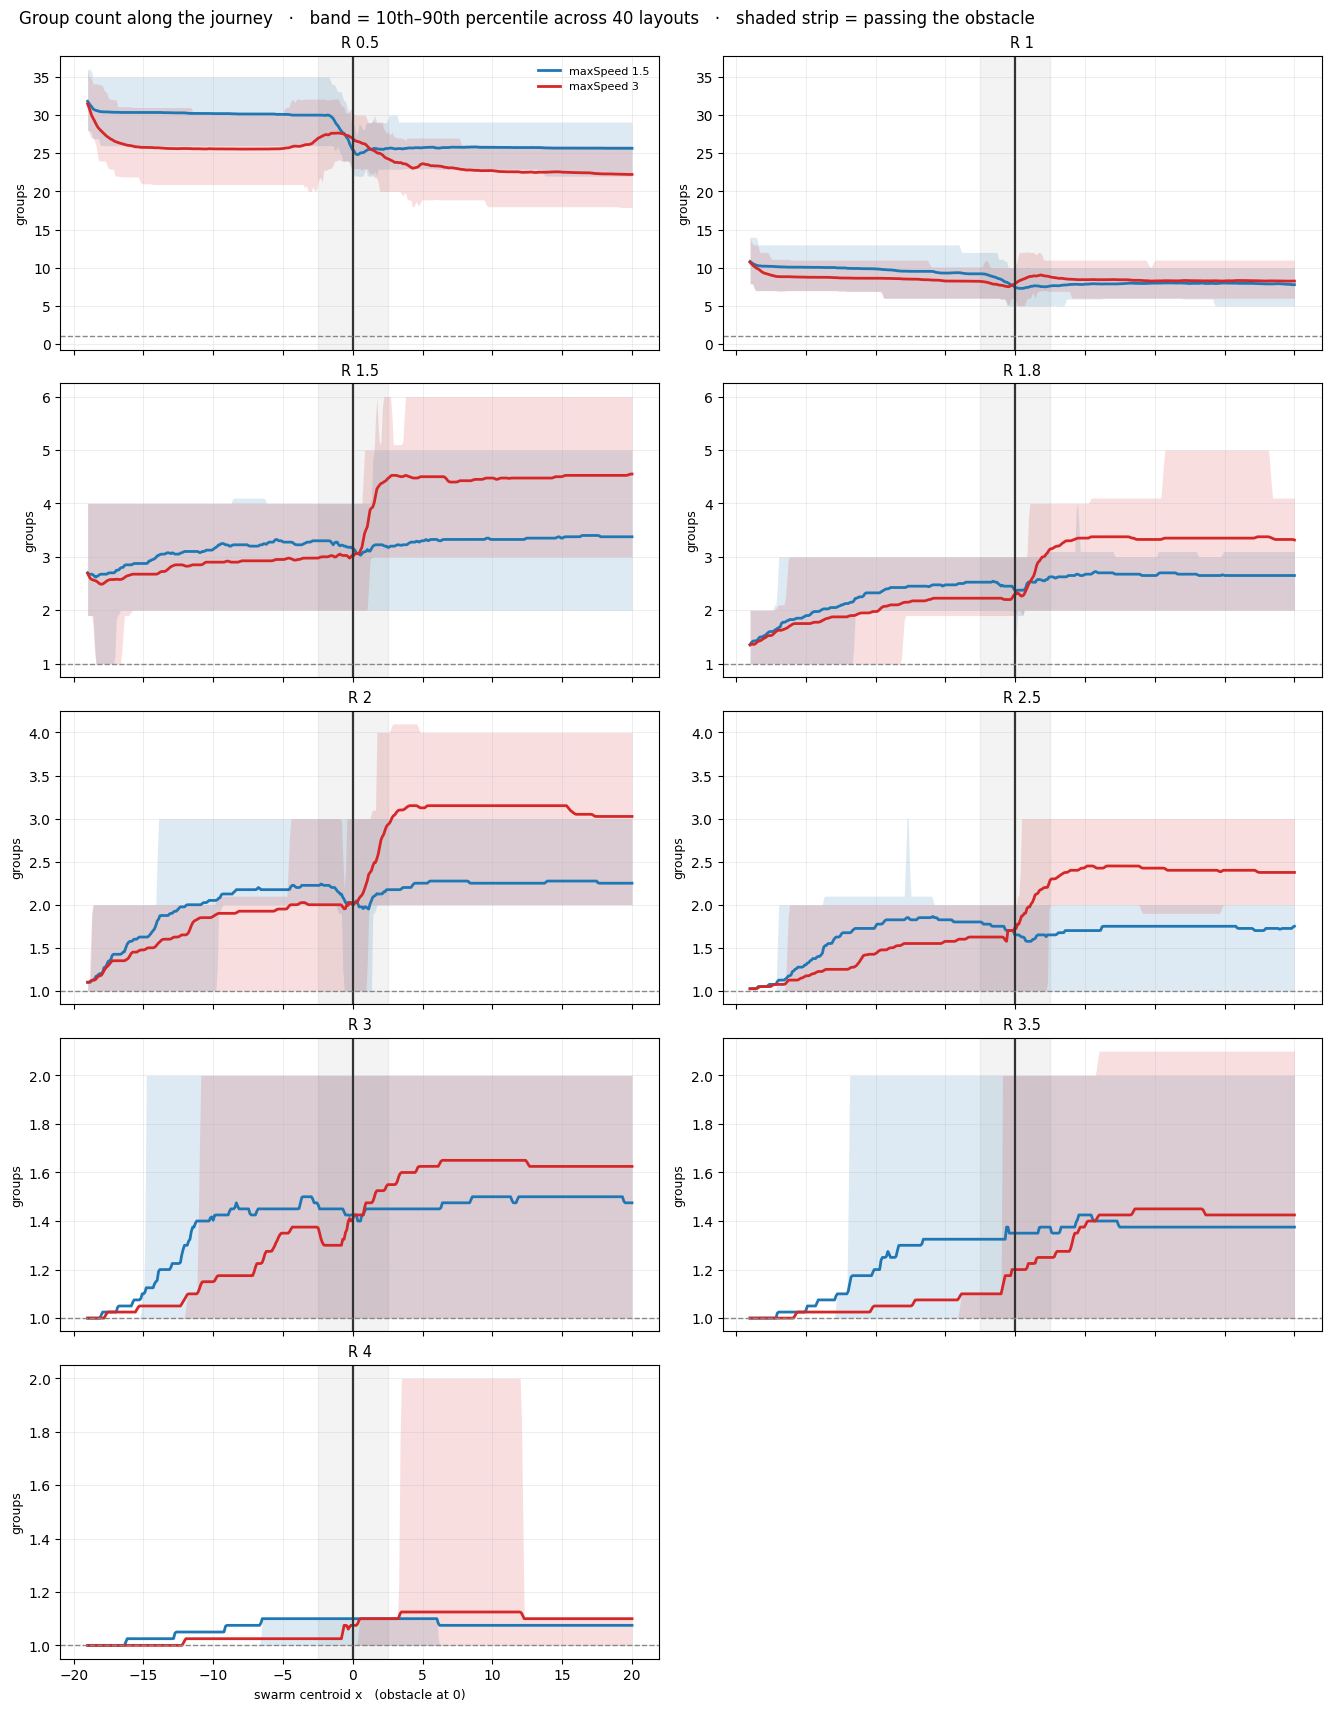

In [5]:
ncols = 2
nrows = int(np.ceil(len(radii) / ncols))
grid_x = np.linspace(BEFORE[0], AFTER[1], 400)
speed_colour = {speeds[0]: "#1f77b4", speeds[-1]: "#d62728"}

fig, axes = plt.subplots(nrows, ncols, figsize=(6.6 * ncols, 3.4 * nrows),
                         sharex=True, squeeze=False, layout="constrained")

for index, R in enumerate(radii):
    ax = axes[index // ncols][index % ncols]

    for sp in speeds:
        sel = [r for r in passage if r["R"] == R and r["speed"] == sp]
        if not sel:
            continue

        # Interpolate onto position, not time, so clips of different length and speed align.
        stack = np.array([np.interp(grid_x, r["cx"], r[GROUPS]) for r in sel])
        mean = stack.mean(axis=0)
        lo = np.percentile(stack, 10, axis=0)
        hi = np.percentile(stack, 90, axis=0)

        c = speed_colour.get(sp, "#888888")
        ax.fill_between(grid_x, lo, hi, color=c, alpha=0.15, linewidth=0)
        ax.plot(grid_x, mean, lw=2.0, color=c, label=f"maxSpeed {sp:g}")

    ax.axvline(OBSTACLE_X, color="#333333", lw=1.6)
    ax.axvspan(AT[0], AT[1], color="#333333", alpha=0.06)
    ax.axhline(1, color="#888888", ls="--", lw=1)
    ax.set_title(f"R {R:g}", fontsize=10.5)
    ax.set_ylabel("groups", fontsize=9)
    ax.grid(alpha=0.25, lw=0.6)
    if index == 0:
        ax.legend(frameon=False, fontsize=8)

for index in range(len(radii), nrows * ncols):
    axes[index // ncols][index % ncols].axis("off")

for row in range(nrows):
    used = [axes[row][c] for c in range(ncols) if row * ncols + c < len(radii)]
    if used:
        lo = min(a.get_ylim()[0] for a in used)
        hi = max(a.get_ylim()[1] for a in used)
        for a in used:
            a.set_ylim(lo, hi)

for c in range(ncols):
    axes[-1][c].set_xlabel("swarm centroid x   (obstacle at 0)", fontsize=9)

fig.suptitle("Group count along the journey   ·   band = 10th–90th percentile across 40 layouts"
             "   ·   shaded strip = passing the obstacle", fontsize=12, ha="left", x=0.01)
plt.show()

## 5. Did they re-form after the obstacle?

The direct answer, per radius and speed.

**recovered** is the share of the split that closed again:

```
recovered = (at − after) / (at − before)
```

1.0 means the flock came back to exactly the grouping it had before the obstacle, 0 means it stayed
as split as it was while passing, and a negative value means it was *more* fragmented afterwards
than during. Clips where the obstacle caused no split at all (`at ≤ before`) have nothing to recover
from and are excluded.

In [6]:
ok = passage_df[passage_df["reached_after"]].copy()
ok["split"] = ok["at"] - ok["before"]
ok["closed"] = ok["at"] - ok["after"]

# Only clips the obstacle actually split have a recovery to measure.
split_only = ok[ok["split"] > 0].copy()
split_only["recovered"] = split_only["closed"] / split_only["split"]

summary = (split_only.groupby(["speed", "R"])
           .agg(clips=("recovered", "size"),
                before=("before", "mean"),
                at=("at", "mean"),
                after=("after", "mean"),
                recovered=("recovered", "mean"))
           .round(2))

split_rate = (ok.assign(did_split=ok["split"] > 0)
              .groupby(["speed", "R"])["did_split"].mean().round(2).rename("split_rate"))

display(summary.join(split_rate))
print("split_rate is the share of the 40 layouts where the obstacle raised the group count at all.")

clips  before     at  after  recovered  split_rate
speed R                                                      
1.5   1.0      2    6.50   7.00   7.00       0.00        0.05
      1.5     10    2.50   3.60   3.90      -0.30        0.25
      1.8     12    1.67   2.83   2.83      -0.04        0.30
      2.0      9    1.56   2.56   2.44       0.11        0.22
      2.5      7    1.14   2.07   2.00       0.14        0.18
      3.0      9    1.00   2.00   2.00       0.00        0.22
      3.5     10    1.05   2.00   2.00       0.00        0.25
      4.0      2    1.00   2.00   2.00       0.00        0.05
3.0   0.5     30   24.20  26.30  22.30       2.74        0.75
      1.0      6    7.83   9.50   9.33       0.08        0.15
      1.5     15    2.37   3.73   4.93      -1.07        0.38
      1.8     16    1.38   2.47   3.62      -1.28        0.40
      2.0     13    1.08   2.42   3.31      -0.74        0.32
      2.5     19    1.00   2.29   2.63      -0.33        0.48
      3.0     12    1.00   2.00   2.00       0.00        0.30
      3.5      5    1.00   2.00   2.40      -0.40        0.12
      4.0      2    1.25   2.00   1.50       0.50        0.05

split_rate is the share of the 40 layouts where the obstacle raised the group count at all.


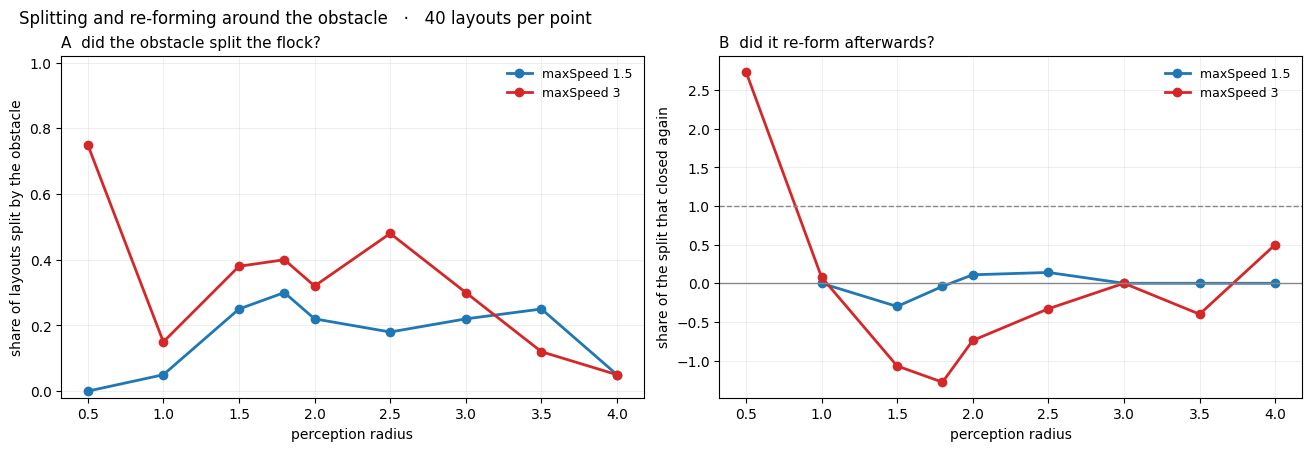

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), layout="constrained")

for sp in speeds:
    c = speed_colour.get(sp, "#888888")

    s = split_rate.xs(sp, level="speed")
    ax[0].plot(s.index, s.values, marker="o", ms=6, lw=2, color=c, label=f"maxSpeed {sp:g}")

    if sp in summary.index.get_level_values("speed"):
        r = summary.xs(sp, level="speed")["recovered"]
        ax[1].plot(r.index, r.values, marker="o", ms=6, lw=2, color=c, label=f"maxSpeed {sp:g}")

ax[0].set_ylim(-0.02, 1.02)
ax[0].set_ylabel("share of layouts split by the obstacle")
ax[0].set_title("A  did the obstacle split the flock?", fontsize=11, loc="left")

ax[1].axhline(1, color="#888888", ls="--", lw=1)
ax[1].axhline(0, color="#888888", lw=1)
ax[1].set_ylabel("share of the split that closed again")
ax[1].set_title("B  did it re-form afterwards?", fontsize=11, loc="left")

for a in ax:
    a.set_xlabel("perception radius")
    a.grid(alpha=0.25, lw=0.6)
    a.legend(frameon=False, fontsize=9)

fig.suptitle("Splitting and re-forming around the obstacle   ·   40 layouts per point",
             fontsize=12, ha="left", x=0.01)
plt.show()

## 6. Where each clip ended up

Every clip as a point: how split it was passing the obstacle against how split it was afterwards.
Points on the diagonal never recovered, points on the floor recovered fully.

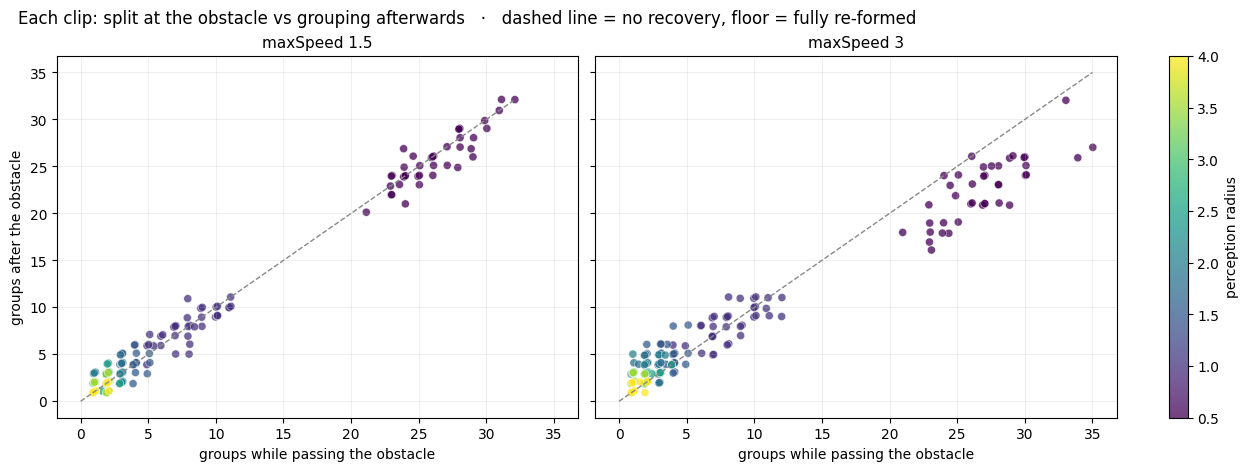

In [8]:
fig, axes = plt.subplots(1, len(speeds), figsize=(6.2 * len(speeds), 4.6),
                         sharex=True, sharey=True, squeeze=False, layout="constrained")
axes = axes[0]

cmap = plt.cm.viridis
norm = plt.Normalize(min(radii), max(radii))

for ax, sp in zip(axes, speeds):
    sub = ok[ok["speed"] == sp]
    jitter = (np.random.default_rng(0).random(len(sub)) - 0.5) * 0.25

    sc = ax.scatter(sub["at"] + jitter, sub["after"] + jitter,
                    c=sub["R"], cmap=cmap, norm=norm, s=34, alpha=0.75,
                    edgecolors="white", linewidths=0.4)

    top = max(sub["at"].max(), sub["after"].max())
    ax.plot([0, top], [0, top], color="#888888", ls="--", lw=1)
    ax.set_xlabel("groups while passing the obstacle")
    ax.set_title(f"maxSpeed {sp:g}", fontsize=11)
    ax.grid(alpha=0.25, lw=0.6)

axes[0].set_ylabel("groups after the obstacle")
fig.colorbar(sc, ax=axes, label="perception radius")
fig.suptitle("Each clip: split at the obstacle vs grouping afterwards   ·   "
             "dashed line = no recovery, floor = fully re-formed",
             fontsize=12, ha="left", x=0.01)
plt.show()

## Notes

- **Position, not time.** Every series in sections 4 onward is interpolated onto the swarm's
  centroid x. That is what lets clips of different length, and both max speeds, be compared on one
  axis.
- **The "after" zone stops at x = 20**, short of the goal area at x ≈ 22. Agents funnelling into a
  target re-merge for reasons unrelated to the obstacle, and including that would inflate recovery.
- **Bands are 10th–90th percentile, not min–max.** With only a handful of groups, one agent
  crossing a perception boundary changes the count by one, so min and max report the extremes of
  that flicker rather than the range of outcomes.
- **`split_rate` matters as much as `recovered`.** A radius where the obstacle never splits the
  flock has a meaningless recovery figure, computed from a handful of clips.